# Initial Data Exploration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
train = pd.read_csv('../data/train.csv')
test = pd.read_csv('../data/test.csv')
sample_submission = pd.read_csv('../submissions/gender_submission.csv')

In [3]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [5]:
sample_submission.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


In [6]:
train.shape

(891, 12)

In [7]:
train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [8]:
train.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

In [9]:
train["Survived"].head() # Target

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

In [10]:
train.set_index("PassengerId", inplace=True)
test.set_index("PassengerId", inplace=True)

In [11]:
train.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [12]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    str    
 3   Sex       891 non-null    str    
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    str    
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    str    
 10  Embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 76.7 KB


In [13]:
train.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [14]:
train.isna().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      2
dtype: int64

In [15]:
train.duplicated().sum()

np.int64(0)

In [16]:
train["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [17]:
train["Pclass"].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

In [18]:
train["Sex"].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [19]:
train["Embarked"].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [20]:
num_attribs = ["Age", "SibSp", "Parch", "Fare"]
cat_attribs = ["Pclass", "Sex", "Embarked"]

## Dataset Documentation

We started by exploring the dataset using `info()` and `describe()` to understand the data types, summary statistics, and missing values.

The analysis showed that **Age**, **Cabin**, and **Embarked** contain missing values, with **Cabin** having a large number of missing entries. We also checked for duplicate rows and found that the dataset contains no duplicates.

Next, we examined the distribution of the categorical features using `value_counts()`. We observed that more passengers did not survive than survived, third class was the most common passenger class, most passengers were male, and the majority embarked from Southampton (`S`).

Finally, we grouped the features into numerical (`Age`, `SibSp`, `Parch`, `Fare`) and categorical (`Pclass`, `Sex`, `Embarked`) features to prepare the data for the preprocessing pipeline later.

# Exploratory Data Analysis (EDA)

In [21]:
train["Survived"].value_counts(normalize=True)

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

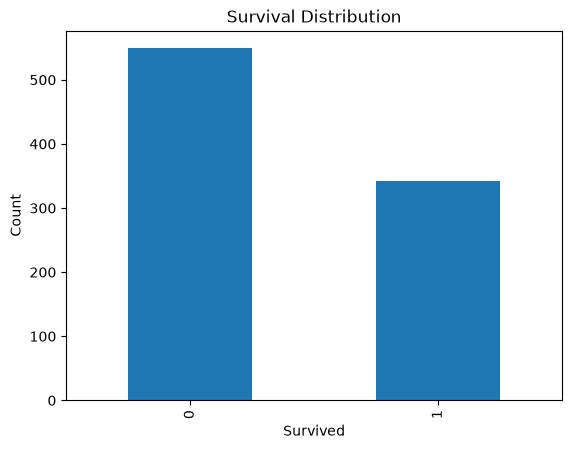

In [22]:
train["Survived"].value_counts().plot(kind="bar")
plt.title("Survival Distribution")
plt.xlabel("Survived")
plt.ylabel("Count")
plt.show()

In [23]:
(train.isna().mean() * 100).sort_values(ascending=False)

Cabin       77.104377
Age         19.865320
Embarked     0.224467
Name         0.000000
Pclass       0.000000
Survived     0.000000
Sex          0.000000
Parch        0.000000
SibSp        0.000000
Fare         0.000000
Ticket       0.000000
dtype: float64

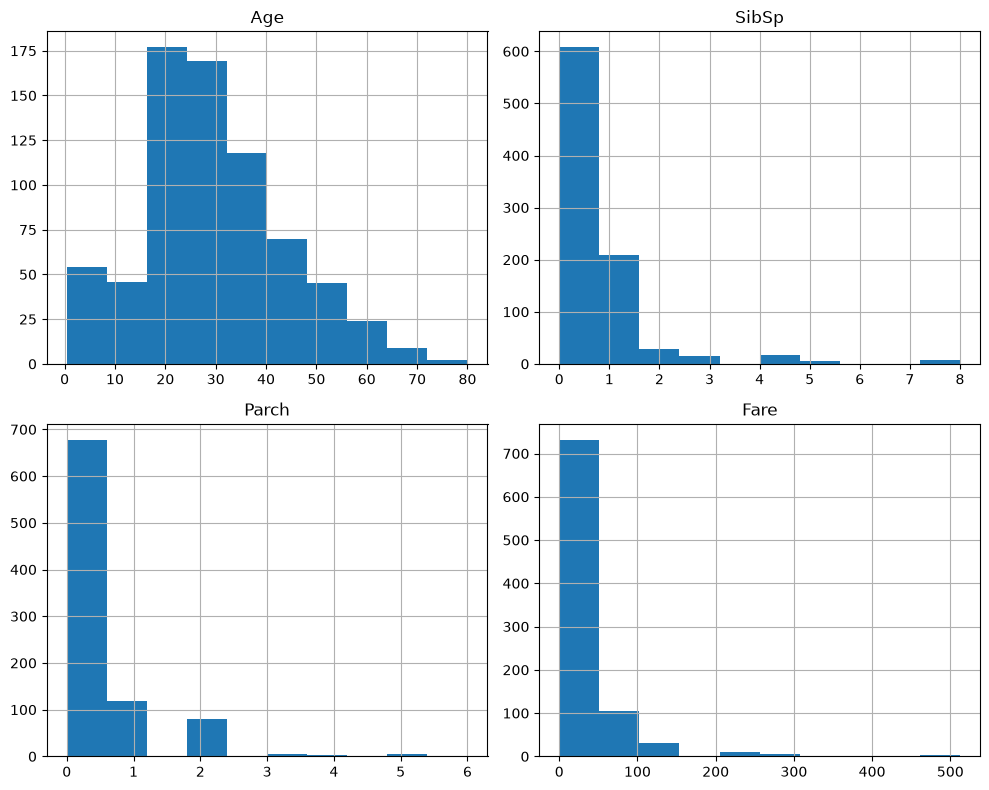

In [24]:
train[num_attribs].hist(figsize=(10, 8))
plt.tight_layout()
plt.show()

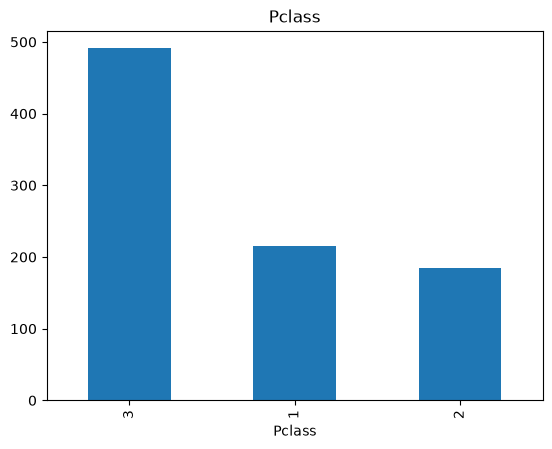

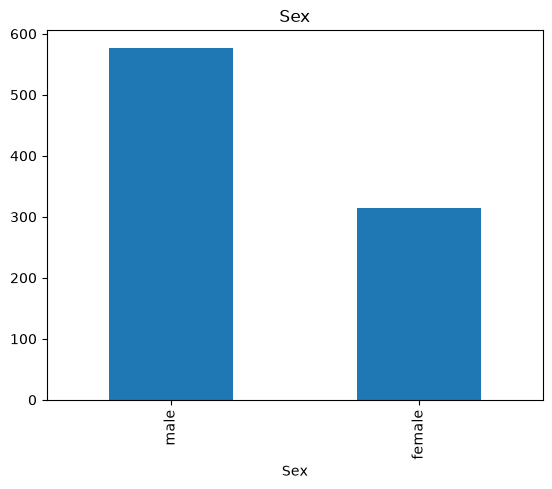

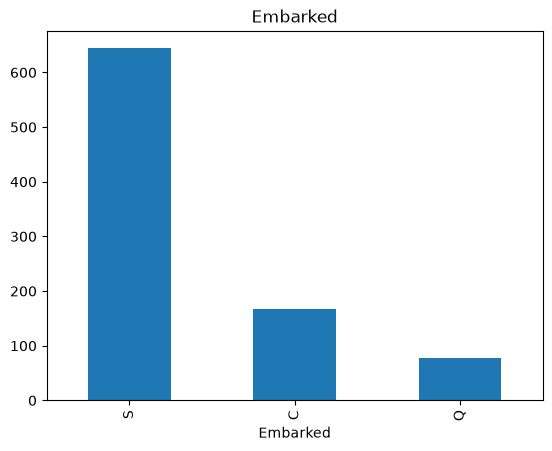

In [25]:
for col in cat_attribs:
    train[col].value_counts().plot(kind="bar")
    plt.title(col)
    plt.show()

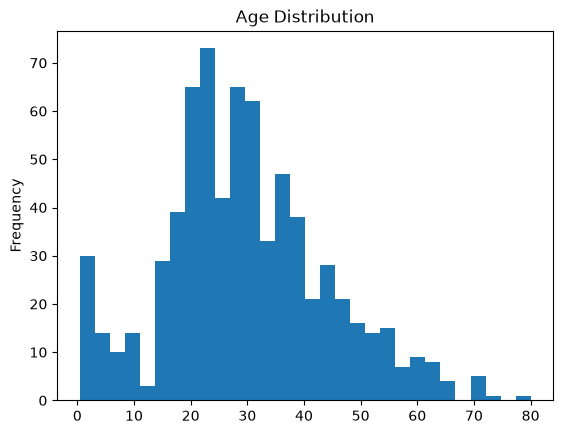

In [26]:
train["Age"].plot(kind="hist", bins=30)
plt.title("Age Distribution")
plt.show()

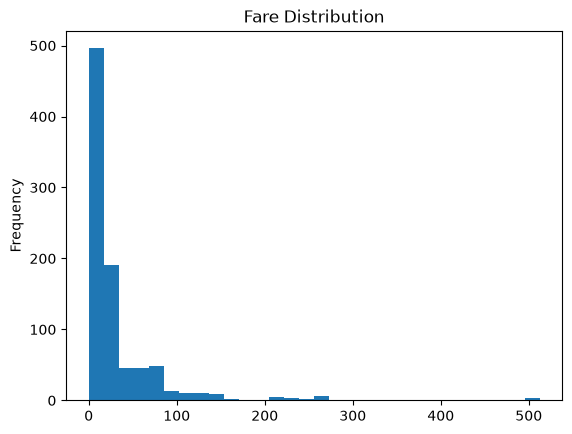

In [27]:
train["Fare"].plot(kind="hist", bins=30)
plt.title("Fare Distribution")
plt.show()

In [28]:
train.groupby("Sex")["Survived"].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [29]:
train.groupby("Pclass")["Survived"].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

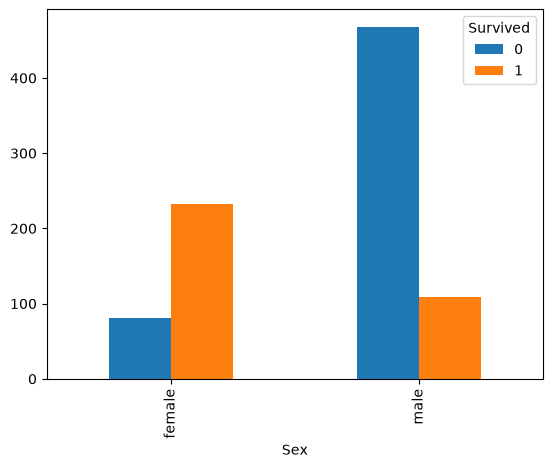

In [30]:
pd.crosstab(train["Sex"], train["Survived"]).plot(kind="bar")
plt.show()

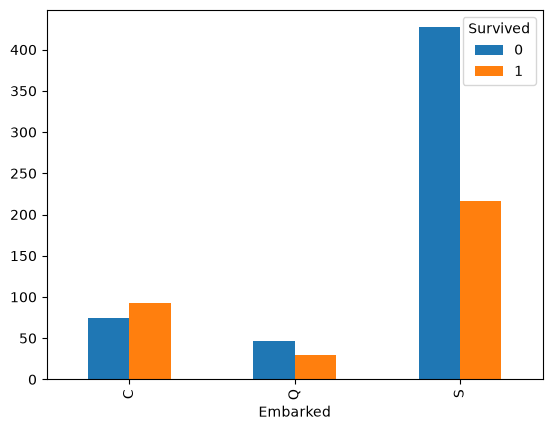

In [31]:
pd.crosstab(train["Embarked"], train["Survived"]).plot(kind="bar")
plt.show()

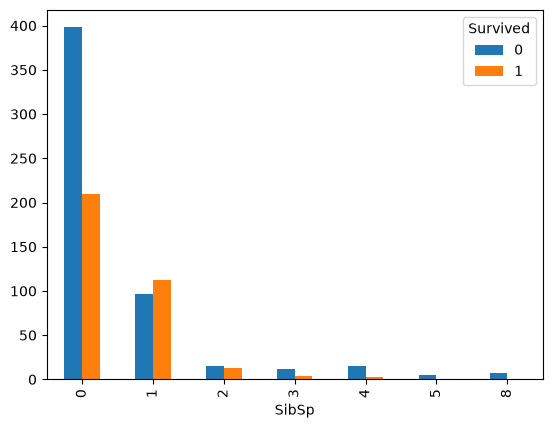

In [32]:
pd.crosstab(train["SibSp"], train["Survived"]).plot(kind="bar")
plt.show()

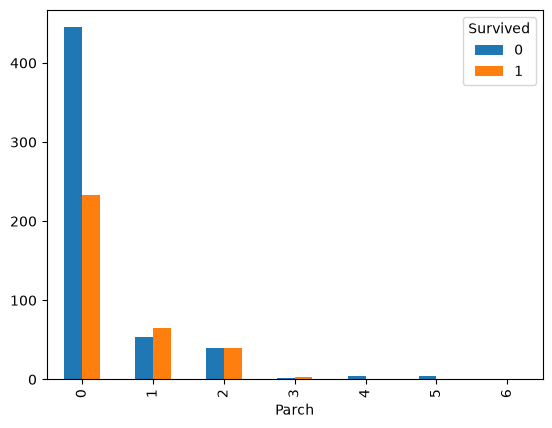

In [33]:
pd.crosstab(train["Parch"], train["Survived"]).plot(kind="bar")
plt.show()

In [34]:
corr = train[num_attribs + ["Survived"]].corr()

corr

,Age,SibSp,Parch,Fare,Survived
Age,1.000000,-0.308247,-0.189119,0.096067,-0.077221
SibSp,-0.308247,1.000000,0.414838,0.159651,-0.035322
Parch,-0.189119,0.414838,1.000000,0.216225,0.081629
Fare,0.096067,0.159651,0.216225,1.000000,0.257307
Survived,-0.077221,-0.035322,0.081629,0.257307,1.000000


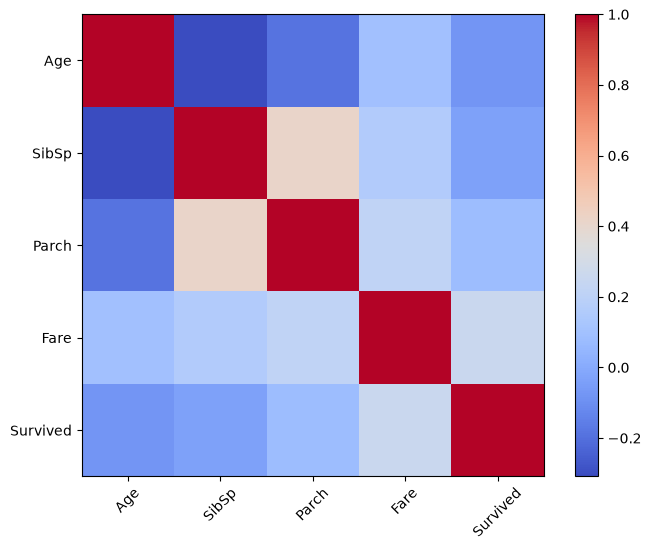

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.imshow(corr, cmap="coolwarm")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar()
plt.show()

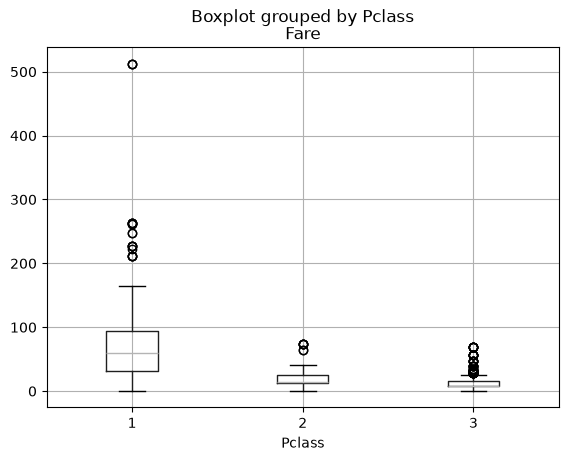

In [36]:
train.boxplot(column="Fare", by="Pclass")
plt.show()

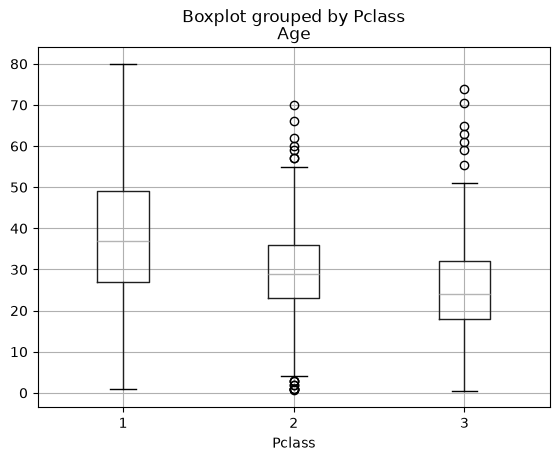

In [37]:
train.boxplot(column="Age", by="Pclass")
plt.show()

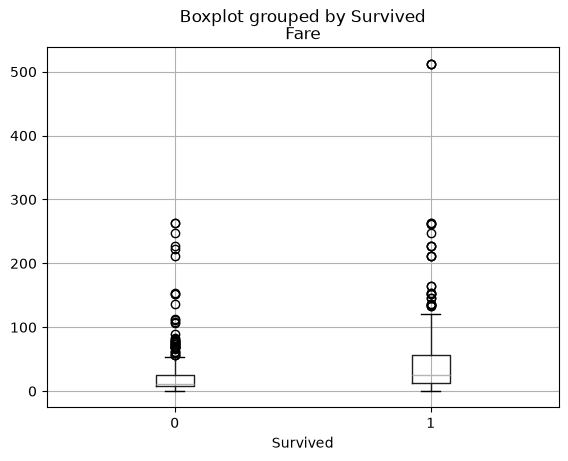

In [38]:
train.boxplot(column="Fare", by="Survived")
plt.show()

## Key Findings

- The target is moderately imbalanced, with approximately 62% of passengers not surviving and 38% surviving.
- Cabin contains a large proportion of missing values (~77%), while Age has around 20% missing values. Embarked contains only a few missing values.
- Most passengers traveled in third class, the majority were male, and most passengers embarked from Southampton (S).
- The Age distribution is concentrated between 20 and 40 years old, while Fare is highly right-skewed with several extreme outliers.
- Female passengers have a significantly higher survival rate than male passengers.
- First-class passengers have the highest survival rate, while third-class passengers have the lowest.
- Passengers in first class generally paid higher fares and tended to be older than passengers in second and third class.
- Passengers who survived generally paid higher fares than those who did not survive, suggesting that Fare is an informative feature for predicting survival.
- Most passengers traveled alone or with a small family (SibSp and Parch equal to 0 or 1).
- Fare has the strongest positive linear correlation with survival among the numerical features, while Age, SibSp, and Parch show only weak linear correlations, indicating that their relationship with survival may be more complex or non-linear.

# Data Preparation

In [39]:
X = train.drop("Survived", axis=1)
y = train["Survived"]

In [40]:
X.head()

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,
1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [41]:
y.head()

PassengerId
1    0
2    1
3    1
4    1
5    0
Name: Survived, dtype: int64

In [42]:
from sklearn.model_selection import train_test_split

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [44]:
X_train.head()

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,
332,1,"Partner, Mr. Austen",male,45.5,0,0,113043,28.5000,C124,S
734,2,"Berriman, Mr. William John",male,23.0,0,0,28425,13.0000,NaN,S
383,3,"Tikkanen, Mr. Juho",male,32.0,0,0,STON/O 2. 3101293,7.9250,NaN,S
705,3,"Hansen, Mr. Henrik Juul",male,26.0,1,0,350025,7.8542,NaN,S
814,3,"Andersson, Miss. Ebba Iris Alfrida",female,6.0,4,2,347082,31.2750,NaN,S


In [45]:
X_test.head()

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,
710,3,"Moubarek, Master. Halim Gonios (""William George"")",male,NaN,1,1,2661,15.2458,NaN,C
440,2,"Kvillner, Mr. Johan Henrik Johannesson",male,31.0,0,0,C.A. 18723,10.5000,NaN,S
841,3,"Alhomaki, Mr. Ilmari Rudolf",male,20.0,0,0,SOTON/O2 3101287,7.9250,NaN,S
721,2,"Harper, Miss. Annie Jessie ""Nina""",female,6.0,0,1,248727,33.0000,NaN,S
40,3,"Nicola-Yarred, Miss. Jamila",female,14.0,1,0,2651,11.2417,NaN,C


In [46]:
y_train.head()

PassengerId
332    0
734    0
383    0
705    0
814    0
Name: Survived, dtype: int64

In [47]:
y_test.head()

PassengerId
710    1
440    0
841    0
721    1
40     1
Name: Survived, dtype: int64

# Preprocessing Pipeline

In [48]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [49]:
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("scaler", StandardScaler())
])

In [50]:
cat_pipeline = Pipeline([
        ("ordinal_encoder", OrdinalEncoder()),
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("cat_encoder", OneHotEncoder(sparse_output=False)),
    ])

In [51]:
preprocess_pipeline = ColumnTransformer([
        ("num", num_pipeline, num_attribs),
        ("cat", cat_pipeline, cat_attribs),
    ])

In [52]:
X_train_ready = preprocess_pipeline.fit_transform(X_train)
X_test_ready = preprocess_pipeline.transform(X_test)

In [53]:
X_train_ready

array([[ 1.29728375, -0.47072241, -0.47934164, ...,  0.        ,
         0.        ,  1.        ],
       [-0.41142846, -0.47072241, -0.47934164, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.27205642, -0.47072241, -0.47934164, ...,  0.        ,
         0.        ,  1.        ],
       ...,
       [ 0.95554131,  1.23056874, -0.47934164, ...,  0.        ,
         0.        ,  1.        ],
       [-1.09491335,  0.37992316,  2.04874166, ...,  0.        ,
         0.        ,  1.        ],
       [-0.56331399, -0.47072241,  0.78470001, ...,  0.        ,
         0.        ,  1.        ]], shape=(712, 12))

In [54]:
X_test_ready

array([[-0.3354857 ,  0.37992316,  0.78470001, ...,  1.        ,
         0.        ,  0.        ],
       [ 0.19611366, -0.47072241, -0.47934164, ...,  0.        ,
         0.        ,  1.        ],
       [-0.63925676, -0.47072241, -0.47934164, ...,  0.        ,
         0.        ,  1.        ],
       ...,
       [ 0.72771301,  0.37992316,  5.8408666 , ...,  0.        ,
         0.        ,  1.        ],
       [-0.86708505, -0.47072241, -0.47934164, ...,  0.        ,
         0.        ,  1.        ],
       [-1.854341  ,  0.37992316,  0.78470001, ...,  0.        ,
         0.        ,  1.        ]], shape=(179, 12))

To prepare the data for model training, a preprocessing pipeline was created using `Pipeline` and `ColumnTransformer`.

The numerical features were imputed using the most frequent value and then standardized with `StandardScaler`. The categorical features were encoded using `OneHotEncoder` after imputing missing values. The preprocessing pipeline was fitted on the training data and then applied to both the training and test sets. Fitting the pipeline only on the training data prevents data leakage, while applying the same learned transformations to the test data ensures consistency.

The transformed datasets (`X_train_ready` and `X_test_ready`) are now numerical and ready to be used for training machine learning models.